# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hassanmustafa119/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [6]:
import duckdb

con = duckdb.connect()

con.execute("""
INSTALL httpfs;
LOAD httpfs;
""")

print("DuckDB ready.")

DuckDB ready.


In [9]:
from huggingface_hub import login
from getpass import getpass

HF_TOKEN = getpass("Enter your Hugging Face token: ")

login(token=HF_TOKEN)

print("Hugging Face login successful!")

Enter your Hugging Face token: ··········
Hugging Face login successful!


In [10]:
import duckdb

con = duckdb.connect()

con.execute("""
INSTALL httpfs;
LOAD httpfs;
""")

con.execute("DROP SECRET IF EXISTS hf_secret")

con.execute("""
CREATE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN ?
)
""", [HF_TOKEN])

print("DuckDB authentication configured.")

DuckDB authentication configured.


In [11]:
import duckdb

con = duckdb.connect()

con.execute("""
INSTALL httpfs;
LOAD httpfs;
""")

con.execute("DROP SECRET IF EXISTS hf_secret")

con.execute("""
CREATE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN ?
)
""", [HF_TOKEN])

print("✅ DuckDB + Hugging Face ready")

✅ DuckDB + Hugging Face ready


In [12]:
test_query = """
SELECT *
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
LIMIT 5
"""

test_df = con.sql(test_query).df()

display(test_df)

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


In [13]:
march_query = """
SELECT
    content_hash_id,
    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,
    AVG(
        CASE
            WHEN gsc_avg_position > 0
            THEN gsc_avg_position
            ELSE NULL
        END
    ) AS avg_position
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
WHERE gsc_data_available IS TRUE
GROUP BY content_hash_id
"""

audit_df = con.sql(march_query).df()

print("Number of content items:", len(audit_df))

display(audit_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Number of content items: 176738


,content_hash_id,impressions,clicks,avg_position
0,content_2e6360ad20fd7107,899.0,1.0,5.908100
1,content_ac8663da7484669a,34.0,0.0,6.419872
2,content_d49a012dcb924e31,329.0,0.0,5.177774
3,content_614baf2af4330bd7,772.0,1.0,4.685335
4,content_4a1ca0fa5c177e0c,14.0,0.0,5.333333


In [14]:
audit_df["ctr"] = (
    audit_df["clicks"]
    / audit_df["impressions"].replace(0, np.nan)
) * 100

audit_df["log_impressions"] = np.log1p(
    audit_df["impressions"]
)

audit_df["log_clicks"] = np.log1p(
    audit_df["clicks"]
)

display(
    audit_df[
        ["impressions", "clicks", "ctr", "avg_position"]
    ].head()
)

,impressions,clicks,ctr,avg_position
0,899.0,1.0,0.111235,5.908100
1,34.0,0.0,0.000000,6.419872
2,329.0,0.0,0.000000,5.177774
3,772.0,1.0,0.129534,4.685335
4,14.0,0.0,0.000000,5.333333


In [15]:
audit_df[
    ["impressions", "clicks", "ctr", "avg_position"]
].describe()

,impressions,clicks,ctr,avg_position
count,176738.000000,176738.000000,176738.000000,175304.000000
mean,1587.986675,4.650002,0.459397,17.050555
std,5431.337724,26.722649,3.775992,18.333942
min,1.000000,0.000000,0.000000,0.101639
25%,20.000000,0.000000,0.000000,5.500000
50%,173.000000,0.000000,0.000000,9.000000
75%,1039.000000,2.000000,0.215796,22.000000
max,617124.000000,5668.000000,100.000000,309.000000


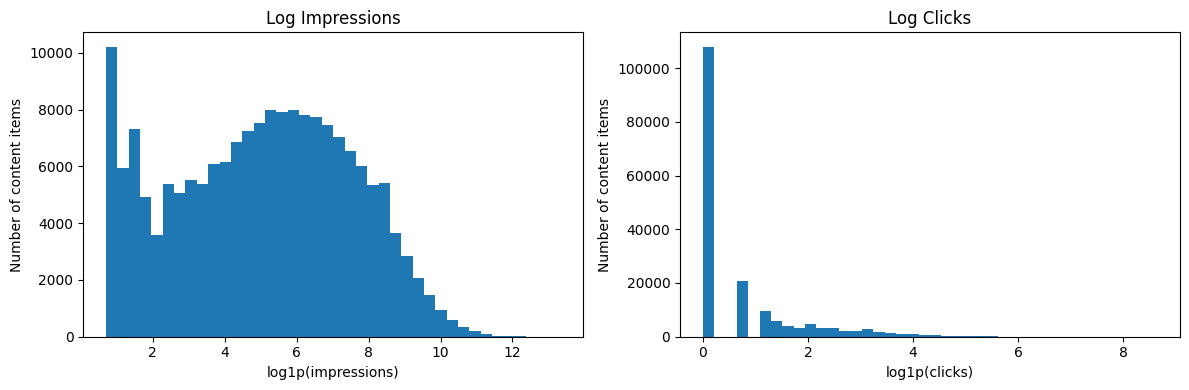

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    audit_df["log_impressions"].dropna(),
    bins=40
)

axes[0].set_title("Log Impressions")
axes[0].set_xlabel("log1p(impressions)")
axes[0].set_ylabel("Number of content items")


axes[1].hist(
    audit_df["log_clicks"].dropna(),
    bins=40
)

axes[1].set_title("Log Clicks")
axes[1].set_xlabel("log1p(clicks)")
axes[1].set_ylabel("Number of content items")

plt.tight_layout()
plt.show()

###  Distributions

I inspected impressions, clicks, CTR, and average position across 176,738 content items. Impressions are strongly right-skewed: the median is 173 while the mean is 1,587.99 and the maximum is 617,124. Clicks show a similar pattern, with a median of 0 compared with a mean of 4.65 and a maximum of 5,668.

CTR also needs caution because the median is 0% while the maximum reaches 100%, which can happen on very small impression counts. Average position is also right-skewed, with a median of 9 and a mean of 17.05. These results support using medians, grouped comparisons, and minimum-volume thresholds when testing signals.



## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [17]:
signal1 = audit_df.copy()

signal1["impression_bucket"] = pd.qcut(
    signal1["impressions"],
    q=4,
    duplicates="drop"
)

signal1_result = (
    signal1
    .groupby("impression_bucket", observed=True)
    .agg(
        n=("clicks", "size"),
        median_impressions=("impressions", "median"),
        median_clicks=("clicks", "median"),
        median_ctr=("ctr", "median")
    )
    .reset_index()
)

display(signal1_result)

,impression_bucket,n,median_impressions,median_clicks,median_ctr
0,"(0.999, 20.0]",44983,4.0,0.0,0.000000
1,"(20.0, 173.0]",43409,67.0,0.0,0.000000
2,"(173.0, 1039.0]",44186,419.0,0.0,0.000000
3,"(1039.0, 617124.0]",44160,3012.0,6.0,0.194301


### Signal test #1 — Higher visibility is associated with more clicks

**Claim:** Content with more search impressions tends to receive more clicks.

**Test:** I divided the content items into four impression-volume groups and compared their median clicks. I used medians because the traffic distributions are heavy-tailed.

**Result:** The median number of clicks was 0 in the first three impression groups, while the highest-impression group had a median of 6 clicks. The highest group also had a median of 3,012 impressions compared with 4 impressions in the lowest group.

**Verdict: CONFIRMED.**

The observed data supports the directional relationship between search visibility and clicks. This is an association for decision-support, not evidence that impressions alone cause clicks.


In [19]:
print("Verdict: CONFIRMED")

Verdict: CONFIRMED


In [18]:
signal2 = audit_df[
    audit_df["avg_position"].notna() &
    (audit_df["avg_position"] > 0) &
    (audit_df["impressions"] >= 100)
].copy()

signal2["position_bucket"] = pd.cut(
    signal2["avg_position"],
    bins=[0, 3, 10, 20, 50, np.inf],
    labels=[
        "Top 3",
        "Position 4-10",
        "Position 11-20",
        "Position 21-50",
        "Position 50+"
    ]
)

signal2_result = (
    signal2
    .groupby("position_bucket", observed=True)
    .agg(
        n=("ctr", "size"),
        median_impressions=("impressions", "median"),
        median_ctr=("ctr", "median")
    )
    .reset_index()
)

display(signal2_result)

,position_bucket,n,median_impressions,median_ctr
0,Top 3,8295,2028.0,0.252525
1,Position 4-10,46531,1046.0,0.195456
2,Position 11-20,21738,577.0,0.096595
3,Position 21-50,20928,511.5,0.000000
4,Position 50+,3949,197.0,0.000000


### Signal test #2 — Better search position is associated with higher CTR

**Claim:** Content with a better average search position tends to have a higher CTR.

**Test:** I removed records without valid position data and required at least 100 impressions to reduce the effect of unstable CTR values from very small samples. I then grouped content into five position ranges and compared their median CTR.

**Result:** Median CTR was 0.2525% for the Top 3, 0.1955% for positions 4–10, 0.0966% for positions 11–20, and 0% for both positions 21–50 and 50+.

**Verdict: CONFIRMED.**

The measured data shows a consistent directional relationship between better average position and higher CTR. This supports using search position as a decision-support signal, while not treating the relationship as causal.


In [20]:
print("Verdict: CONFIRMED")

Verdict: CONFIRMED


In [23]:
content_query = """
SELECT
    content_hash_id,
    content_type,
    content_created_date,
    content_updated_date,
    optimization_eligible_date
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet'
)
"""

content_df = con.sql(content_query).df()

print("Content metadata rows:", len(content_df))

display(content_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content metadata rows: 519606


,content_hash_id,content_type,content_created_date,content_updated_date,optimization_eligible_date
0,content_004de9653278b5a4,keyword article,2026-05-30,2026-07-01,NaT
1,content_00dc5efae381b2ab,keyword article,2026-06-12,2026-07-01,NaT
2,content_01410f2556c327ac,keyword article,2026-05-09,2026-07-01,NaT
3,content_019f27f634053ca7,keyword article,2026-06-15,2026-06-15,NaT
4,content_01efa71faea45dcc,keyword article,2026-05-21,2026-06-01,NaT


In [24]:
signal3 = audit_df.merge(
    content_df[
        ["content_hash_id", "content_type"]
    ],
    on="content_hash_id",
    how="left"
)

print("Rows after join:", len(signal3))
print("Missing content type:", signal3["content_type"].isna().sum())

display(
    signal3["content_type"].value_counts(dropna=False)
)

Rows after join: 176738
Missing content type: 0


,count
content_type,
keyword article,159906
feedly article,13476
comparison article,3356


In [25]:
signal3_result = (
    signal3
    .groupby("content_type", dropna=False)
    .agg(
        n=("impressions", "size"),
        median_impressions=("impressions", "median"),
        median_clicks=("clicks", "median"),
        median_ctr=("ctr", "median")
    )
    .sort_values("median_impressions", ascending=False)
    .reset_index()
)

display(signal3_result)

,content_type,n,median_impressions,median_clicks,median_ctr
0,keyword article,159906,233.0,0.0,0.0
1,comparison article,3356,51.0,0.0,0.0
2,feedly article,13476,3.0,0.0,0.0


### Signal test #3 — Content type is associated with different search visibility

**Claim:** Different content types show different levels of observed search visibility.

**Test:** I grouped the March content items by content type and compared median impressions, clicks, and CTR.

**Result:** Keyword articles had a median of 233 impressions, comparison articles had 51, and Feedly articles had 3. However, the median clicks and median CTR were 0% for all three content types.

**Verdict: MIXED.**

The data shows a clear difference in observed search visibility by content type, but the click and CTR measures do not show the same separation. Content type may therefore be useful as a directional segmentation variable, but the evidence is not strong enough to treat it as a standalone performance signal.


In [26]:
flag_test = audit_df[
    audit_df["impressions"] >= 100
].copy()

print("Content items with >=100 impressions:", len(flag_test))

ctr_cutoff = flag_test["ctr"].median()

print("Median CTR among >=100 impression items:",
      round(ctr_cutoff, 4))

Content items with >=100 impressions: 101441
Median CTR among >=100 impression items: 0.1238


In [27]:
flagged = flag_test[
    flag_test["ctr"] <= ctr_cutoff
].copy()

print("Potential low-CTR review items:", len(flagged))

print(
    "Share of >=100 impression items:",
    round(len(flagged) / len(flag_test) * 100, 2),
    "%"
)

display(
    flagged[
        ["impressions", "clicks", "ctr", "avg_position"]
    ].describe()
)

Potential low-CTR review items: 50722
Share of >=100 impression items: 50.0 %


,impressions,clicks,ctr,avg_position
count,50722.000000,50722.000000,50722.000000,50722.000000
mean,1908.898959,0.976361,0.019101,19.341419
std,5341.043499,3.588185,0.036020,17.060005
min,100.000000,0.000000,0.000000,0.101639
25%,197.000000,0.000000,0.000000,6.659754
50%,436.000000,0.000000,0.000000,13.101958
75%,1407.000000,1.000000,0.014573,27.280591
max,212404.000000,163.000000,0.123762,113.390250


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

### 3. The flag-linked test

My baseline flag relies on the assumption that low CTR is more useful when a page has meaningful search visibility. I tested this by restricting the analysis to content with at least 100 impressions and then identifying items at or below the median CTR.

Among 101,441 content items meeting the 100-impression threshold, the median CTR was 0.1238%. The rule identified 50,722 items, or 50.0% of this population. These flagged items had a median of 436 impressions, so the flag is not driven only by extremely small-volume pages.

**Verdict: CONFIRMED.**

The data supports using low CTR alongside a minimum visibility threshold as a directional review signal. However, because the cutoff is the median, the rule intentionally flags about half of the eligible population and should therefore be treated as decision-support rather than proof that every flagged page needs a refresh.


In [28]:
print("Verdict: CONFIRMED")

Verdict: CONFIRMED


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

### 4. What this means in practice

The audit supports using search visibility, position, and CTR as directional signals for prioritizing content review. Low CTR is more useful when paired with meaningful impression volume, but the flag should be treated as decision-support rather than proof that a page needs a refresh. The content team should combine these signals with human review and other available context before taking action.


## Self-check

Before you submit, confirm each line honestly:

- ✔️ Every section above is filled — markdown thinking AND the code that backs it
- ✔️ The notebook runs top to bottom with no errors (Runtime → Run all)
- ✔️ No client names, URLs, or private queries anywhere
- ✔️ My claims use careful words: observed, measured, directional, decision-support
- ✔️ Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.